# Notebook 1: Sanity Checks

Basic distribution checks on the master dataset.
Covers score histograms, topic/format distributions, token counts, domain Zipf plot, and heuristic feature distributions.

In [1]:
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings('ignore')

# Make config importable from the notebook's directory
NB_DIR = Path('.').resolve()
if str(NB_DIR) not in sys.path:
    sys.path.insert(0, str(NB_DIR))

import config

sns.set_theme(style='whitegrid')

FIGURES_DIR = NB_DIR / 'figures'
FIGURES_DIR.mkdir(exist_ok=True)

def savefig(name):
    path = FIGURES_DIR / name
    plt.tight_layout()
    plt.savefig(path, dpi=150, bbox_inches='tight')
    print(f'Saved: {path}')
    plt.show()
    plt.close()

TOPIC_NAMES = {
    0: 'Adult', 1: 'Art & Design', 2: 'Software Dev.', 3: 'Crime & Law',
    4: 'Education & Jobs', 5: 'Hardware', 6: 'Entertainment', 7: 'Social Life',
    8: 'Fashion & Beauty', 9: 'Finance & Business', 10: 'Food & Dining',
    11: 'Games', 12: 'Health', 13: 'History', 14: 'Home & Hobbies',
    15: 'Industrial', 16: 'Literature', 17: 'Politics', 18: 'Religion',
    19: 'Science & Tech.', 20: 'Software', 21: 'Sports & Fitness',
    22: 'Transportation', 23: 'Travel'
}

FORMAT_NAMES = {
    0: 'Academic Writing', 1: 'Content Listing', 2: 'Creative Writing',
    3: 'Customer Support', 4: 'Comment Section', 5: 'FAQ', 6: 'Truncated',
    7: 'Knowledge Article', 8: 'Legal Notices', 9: 'Listicle',
    10: 'News Article', 11: 'Nonfiction Writing', 12: 'About (Org.)',
    13: 'News (Org.)', 14: 'About (Pers.)', 15: 'Personal Blog',
    16: 'Product Page', 17: 'Q&A', 18: 'Spam/Ads', 19: 'Structured Data',
    20: 'Documentation', 21: 'Audio Transcript', 22: 'Tutorial', 23: 'User Review'
}

print('Setup complete.')

Setup complete.


In [2]:
# Load master.parquet
df = pd.read_parquet(config.MASTER_PARQUET)
print(f'Loaded {len(df):,} documents, {df.shape[1]} columns')
print(f'Columns: {list(df.columns)}')

# NaN summary for quality scores
SCORE_COLS = [
    'dclm_score', 'fwedu_score', 'fwedu_rounded',
    'pc_arc_easy', 'pc_piqa', 'pc_sciq', 'pc_lambada_es',
    'qr_writing_style', 'qr_required_expertise', 'qr_facts_and_trivia', 'qr_educational_value'
]
# Keep only columns that actually exist
SCORE_COLS = [c for c in SCORE_COLS if c in df.columns]

nan_summary = pd.DataFrame({
    'n_nonnan': df[SCORE_COLS].notna().sum(),
    'pct_coverage': (df[SCORE_COLS].notna().mean() * 100).round(1),
    'mean': df[SCORE_COLS].mean().round(4),
    'std': df[SCORE_COLS].std().round(4),
    'min': df[SCORE_COLS].min().round(4),
    'max': df[SCORE_COLS].max().round(4),
})
print('\nScore column summary:')
display(nan_summary)

Loaded 2,263,456 documents, 56 columns
Columns: ['shard_idx', 'doc_idx', 'topic', 'format', 'cluster24', 'dclm_score', 'fwedu_score', 'fwedu_rounded', 'token_count', 'url', 'url_netloc', 'url_registered_domain', 'char_count', 'word_count', 'mean_word_length', 'frac_alpha', 'frac_digit', 'frac_punctuation', 'frac_uppercase', 'frac_lines_terminal_punct', 'frac_lines_bullet', 'type_token_ratio', 'stopword_fraction', 'ngram_rep_2', 'ngram_rep_3', 'ngram_rep_4', 'num_lines', 'mean_line_length', 'pc_arc_easy', 'pc_piqa', 'pc_sciq', 'pc_lambada_es', 'qr_writing_style', 'qr_required_expertise', 'qr_facts_and_trivia', 'qr_educational_value', 'dclm_score_pct_topic', 'dclm_score_pct_format', 'fwedu_score_pct_topic', 'fwedu_score_pct_format', 'pc_arc_easy_pct_topic', 'pc_arc_easy_pct_format', 'pc_piqa_pct_topic', 'pc_piqa_pct_format', 'pc_sciq_pct_topic', 'pc_sciq_pct_format', 'pc_lambada_es_pct_topic', 'pc_lambada_es_pct_format', 'qr_writing_style_pct_topic', 'qr_writing_style_pct_format', 'qr_re


Score column summary:


,n_nonnan,pct_coverage,mean,std,min,max
dclm_score,2263456,100.0,0.0162,0.0795,-0.0000,1.0000
fwedu_score,292846,12.9,1.1222,0.6523,-0.8008,4.7500
fwedu_rounded,2263456,100.0,1.1336,0.6946,0.0000,5.0000
pc_arc_easy,2263456,100.0,0.7648,0.1383,-0.0000,1.0000
pc_piqa,2263456,100.0,0.8077,0.1232,-0.0000,1.0000
pc_sciq,2263456,100.0,0.8243,0.1210,0.0000,1.0000
pc_lambada_es,2263456,100.0,0.1350,0.1017,-0.0000,0.9999
qr_writing_style,974877,43.1,-0.1072,2.4839,-8.0666,10.1963
qr_required_expertise,974877,43.1,-1.4465,2.6112,-8.5625,10.6250
qr_facts_and_trivia,974877,43.1,-0.4437,2.0097,-6.6250,9.5625


Saved: C:\Angikar\ANGIKAR_STANFORD\SECOND_YEAR\SPRING_2026\Courses\STATS_305C\WebOrganizer\milestone2\figures\01_score_histograms.png


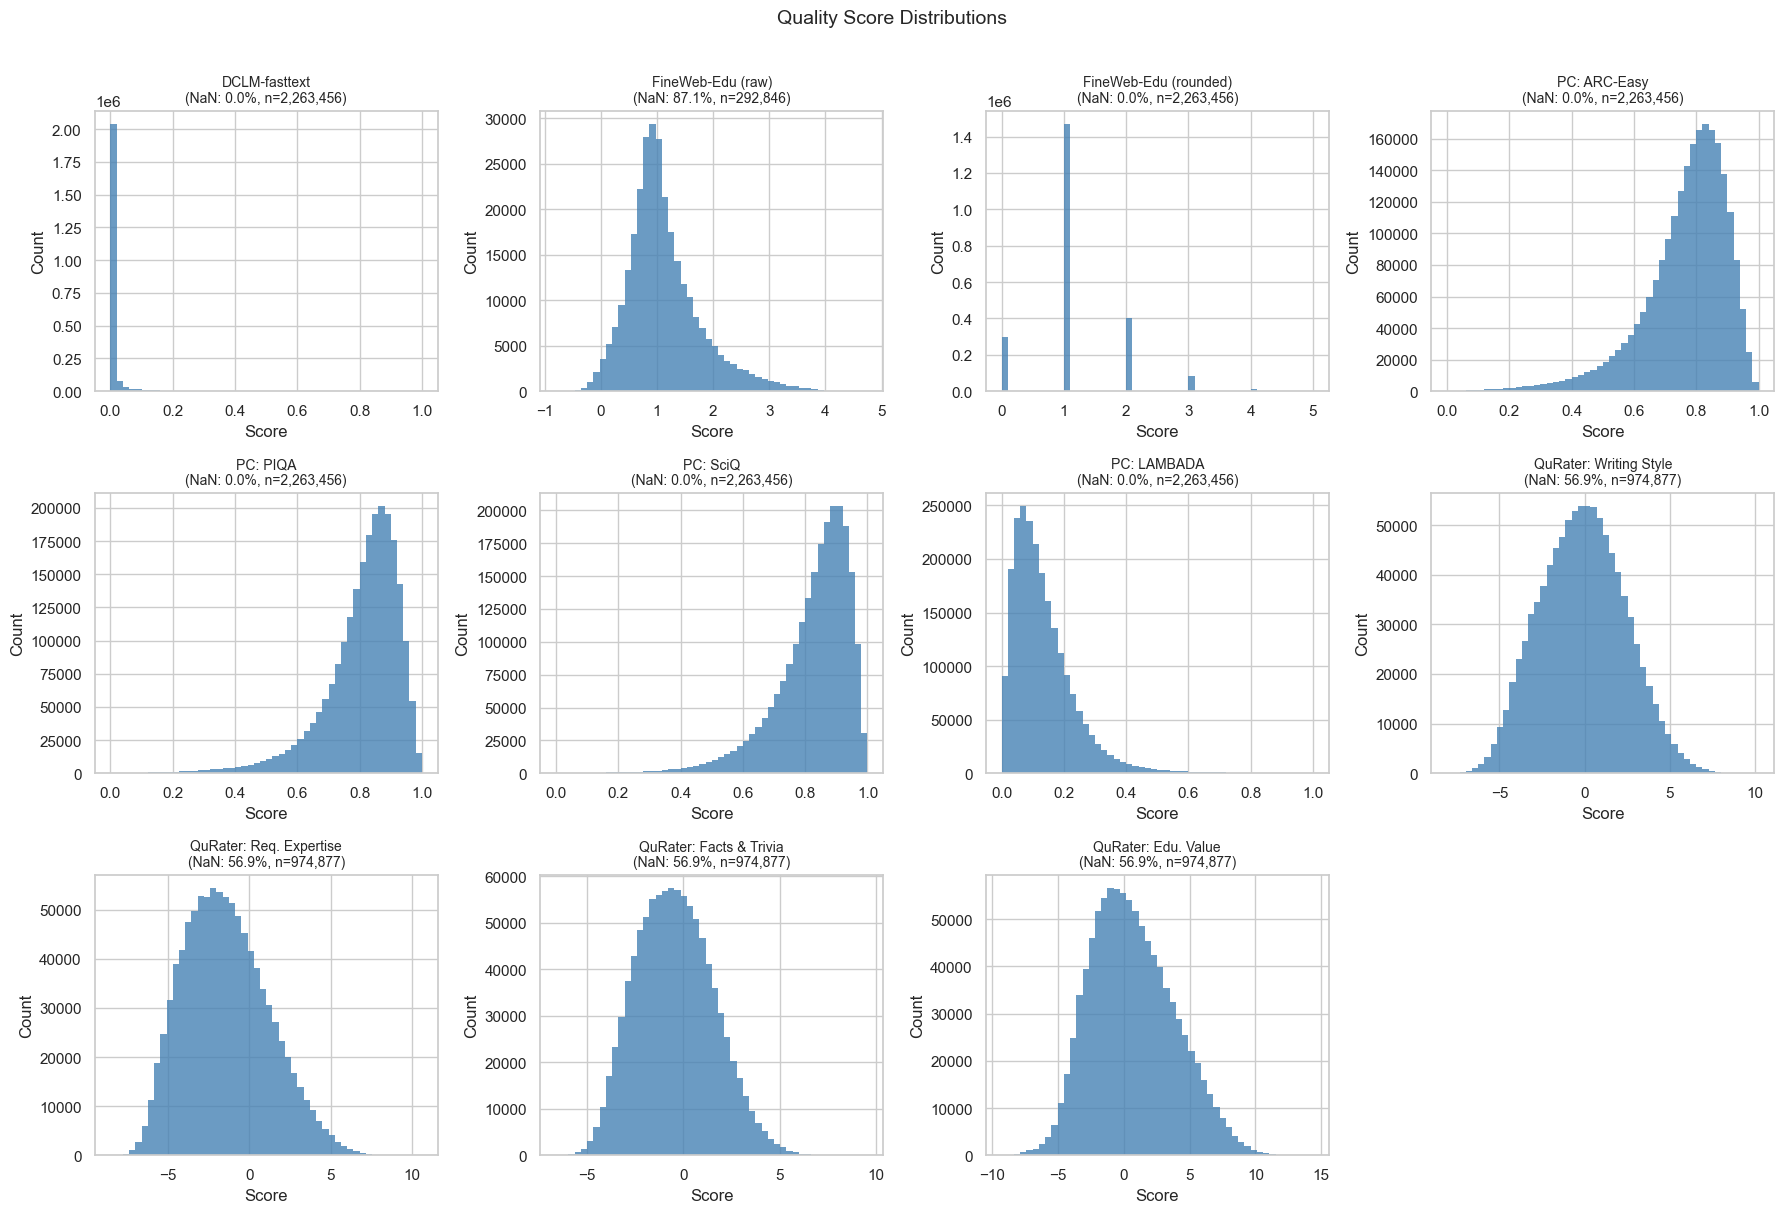

In [3]:
# --- Cell 3: Score histograms ---

# Build display names for scores
SCORE_DISPLAY = {
    'dclm_score': 'DCLM-fasttext',
    'fwedu_score': 'FineWeb-Edu (raw)',
    'fwedu_rounded': 'FineWeb-Edu (rounded)',
    'pc_arc_easy': 'PC: ARC-Easy',
    'pc_piqa': 'PC: PIQA',
    'pc_sciq': 'PC: SciQ',
    'pc_lambada_es': 'PC: LAMBADA',
    'qr_writing_style': 'QuRater: Writing Style',
    'qr_required_expertise': 'QuRater: Req. Expertise',
    'qr_facts_and_trivia': 'QuRater: Facts & Trivia',
    'qr_educational_value': 'QuRater: Edu. Value',
}

plot_scores = [c for c in SCORE_COLS if c in df.columns]
n_scores = len(plot_scores)
n_cols = 4
n_rows = int(np.ceil(n_scores / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(plot_scores):
    ax = axes[i]
    s = df[col].dropna()
    pct_nan = df[col].isna().mean() * 100
    s.hist(bins=50, ax=ax, color='steelblue', edgecolor='none', alpha=0.8)
    title = SCORE_DISPLAY.get(col, col)
    ax.set_title(f'{title}\n(NaN: {pct_nan:.1f}%, n={len(s):,})', fontsize=10)
    ax.set_xlabel('Score')
    ax.set_ylabel('Count')

# Hide unused axes
for j in range(n_scores, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Quality Score Distributions', fontsize=14, y=1.01)
savefig('01_score_histograms.png')

Saved: C:\Angikar\ANGIKAR_STANFORD\SECOND_YEAR\SPRING_2026\Courses\STATS_305C\WebOrganizer\milestone2\figures\01_topic_format_dist.png


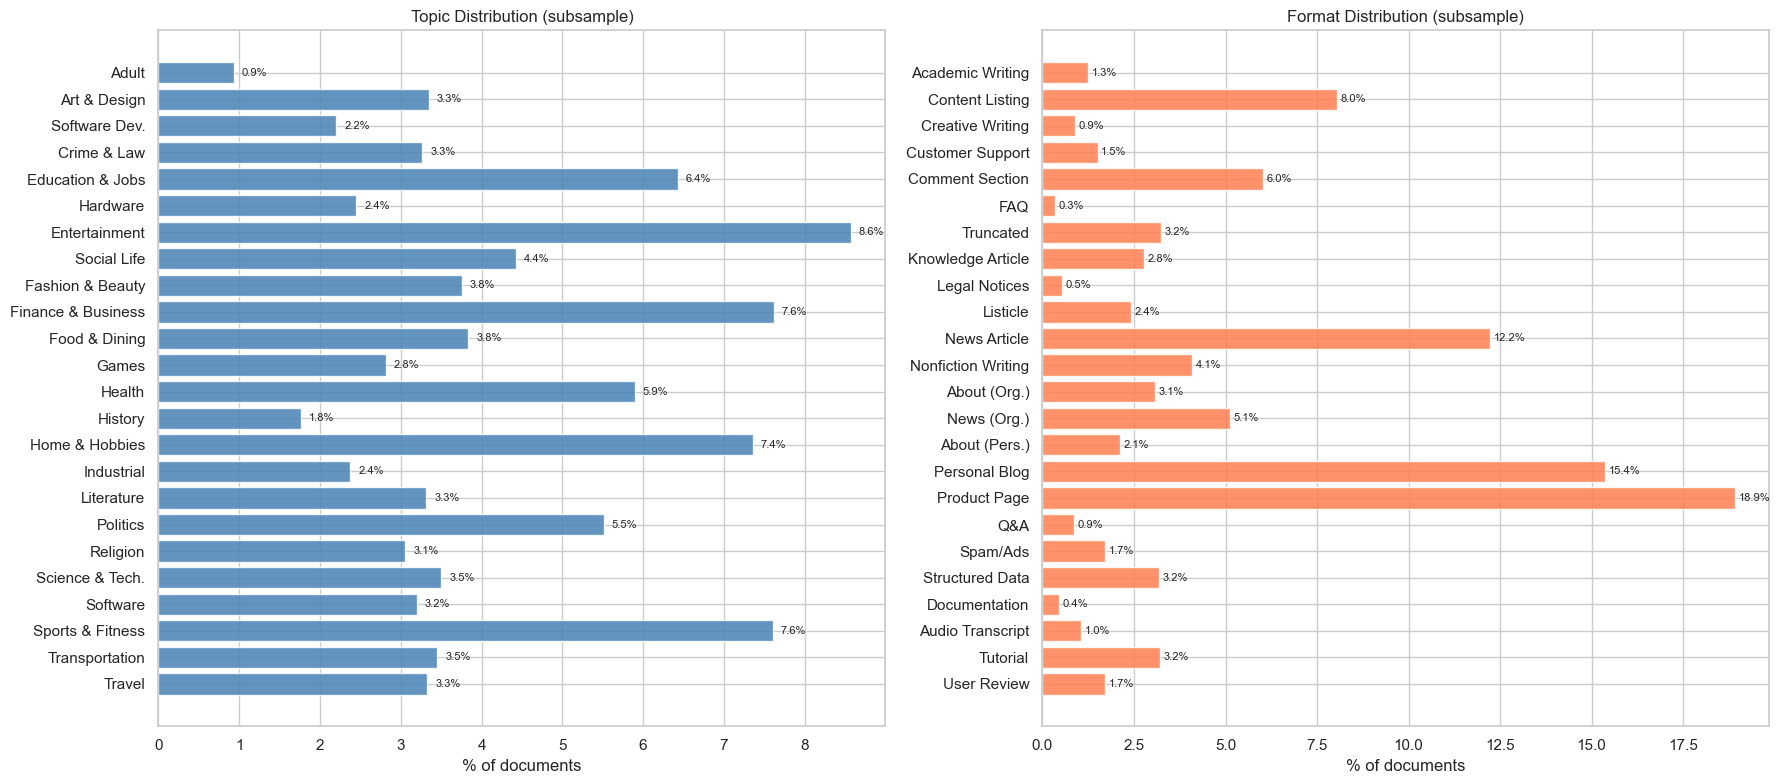

In [4]:
# --- Cell 4: Topic & format bar charts ---

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Topic distribution
ax = axes[0]
topic_counts = df['topic'].value_counts().sort_index()
topic_labels = [TOPIC_NAMES.get(i, str(i)) for i in topic_counts.index]
topic_pct = topic_counts / topic_counts.sum() * 100
bars = ax.barh(topic_labels, topic_pct.values, color='steelblue', alpha=0.85)
ax.set_xlabel('% of documents')
ax.set_title('Topic Distribution (subsample)', fontsize=12)
ax.invert_yaxis()
# Annotate bars
for bar, val in zip(bars, topic_pct.values):
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height() / 2,
            f'{val:.1f}%', va='center', fontsize=8)

# Format distribution
ax = axes[1]
format_counts = df['format'].value_counts().sort_index()
format_labels = [FORMAT_NAMES.get(i, str(i)) for i in format_counts.index]
format_pct = format_counts / format_counts.sum() * 100
bars = ax.barh(format_labels, format_pct.values, color='coral', alpha=0.85)
ax.set_xlabel('% of documents')
ax.set_title('Format Distribution (subsample)', fontsize=12)
ax.invert_yaxis()
for bar, val in zip(bars, format_pct.values):
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height() / 2,
            f'{val:.1f}%', va='center', fontsize=8)

savefig('01_topic_format_dist.png')

Saved: C:\Angikar\ANGIKAR_STANFORD\SECOND_YEAR\SPRING_2026\Courses\STATS_305C\WebOrganizer\milestone2\figures\01_token_counts.png


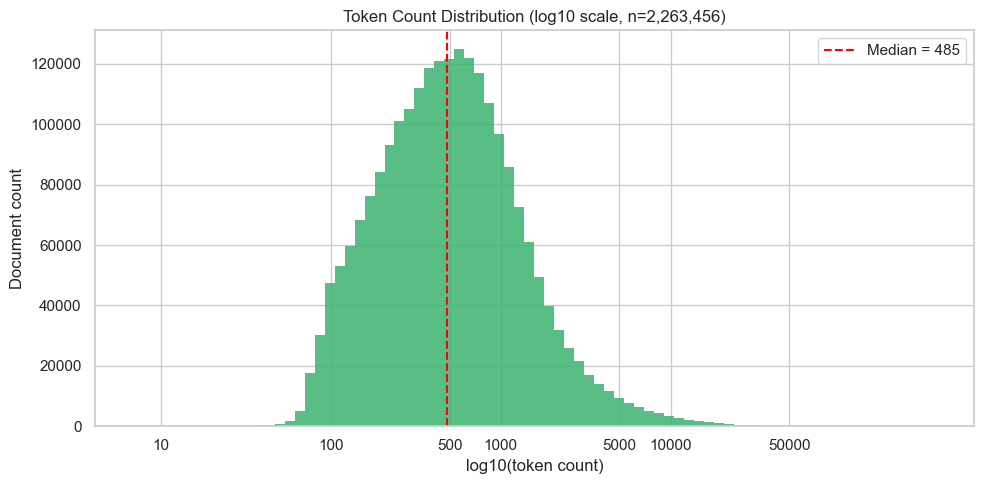

In [5]:
# --- Cell 5: Token count histogram (log-scale x) ---

fig, ax = plt.subplots(figsize=(10, 5))
tok = df['token_count'].dropna()
tok_pos = tok[tok > 0]
log_tok = np.log10(tok_pos)
ax.hist(log_tok, bins=80, color='mediumseagreen', edgecolor='none', alpha=0.85)
ax.set_xlabel('log10(token count)')
ax.set_ylabel('Document count')
ax.set_title(f'Token Count Distribution (log10 scale, n={len(tok_pos):,})')

# Add x-axis ticks showing actual values
tick_vals = [10, 100, 500, 1000, 5000, 10000, 50000]
ax.set_xticks([np.log10(v) for v in tick_vals])
ax.set_xticklabels([str(v) for v in tick_vals])

# Median annotation
med = np.median(tok_pos)
ax.axvline(np.log10(med), color='red', linestyle='--', label=f'Median = {med:.0f}')
ax.legend()

savefig('01_token_counts.png')

Total unique domains:  798,128
Domains with >100 docs: 1,862
Domains with >1000 docs: 38

Top 15 domains:
url_registered_domain
blogspot.com           127798
wordpress.com           47710
wikia.com                6841
cbslocal.com             4086
urbandictionary.com      3509
stackexchange.com        3443
wikipedia.org            2948
yahoo.com                2266
blogspot.co.uk           2100
typepad.com              2056
wsj.com                  1920
cnn.com                  1812
nytimes.com              1780
theguardian.com          1712
livejournal.com          1634


Saved: C:\Angikar\ANGIKAR_STANFORD\SECOND_YEAR\SPRING_2026\Courses\STATS_305C\WebOrganizer\milestone2\figures\01_domain_zipf.png


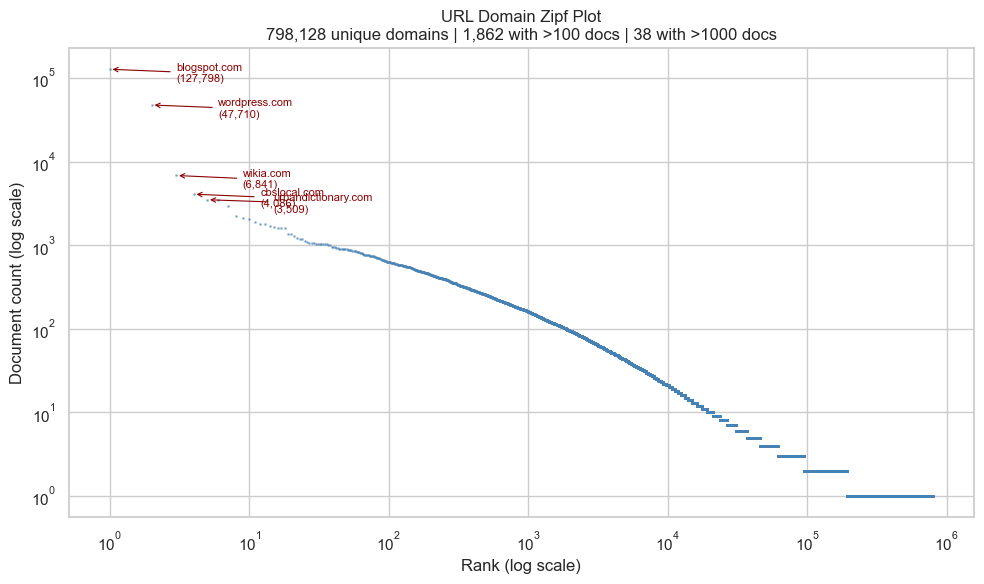

In [6]:
# --- Cell 6: URL domain Zipf plot ---

domain_col = 'url_registered_domain' if 'url_registered_domain' in df.columns else 'url_netloc'
domain_counts = df[domain_col].dropna().value_counts()
n_domains = len(domain_counts)
ranks = np.arange(1, n_domains + 1)
freqs = domain_counts.values

n_gt100 = (freqs > 100).sum()
n_gt1000 = (freqs > 1000).sum()

fig, ax = plt.subplots(figsize=(10, 6))
ax.loglog(ranks, freqs, '.', markersize=2, alpha=0.5, color='steelblue')

# Annotate top 5
for rank, (dom, cnt) in enumerate(domain_counts.head(5).items(), 1):
    ax.annotate(f'{dom}\n({cnt:,})',
                xy=(rank, cnt),
                xytext=(rank * 3, cnt * 0.7),
                fontsize=8, color='darkred',
                arrowprops=dict(arrowstyle='->', color='darkred', lw=0.8))

ax.set_xlabel('Rank (log scale)')
ax.set_ylabel('Document count (log scale)')
ax.set_title(
    f'URL Domain Zipf Plot\n'
    f'{n_domains:,} unique domains | '
    f'{n_gt100:,} with >100 docs | '
    f'{n_gt1000:,} with >1000 docs'
)

print(f'Total unique domains:  {n_domains:,}')
print(f'Domains with >100 docs: {n_gt100:,}')
print(f'Domains with >1000 docs: {n_gt1000:,}')
print(f'\nTop 15 domains:')
print(domain_counts.head(15).to_string())

savefig('01_domain_zipf.png')

Plotting 16 heuristic features


Highly skewed features (|skew|>5): ['char_count', 'word_count', 'num_lines', 'mean_line_length']


Saved: C:\Angikar\ANGIKAR_STANFORD\SECOND_YEAR\SPRING_2026\Courses\STATS_305C\WebOrganizer\milestone2\figures\01_heuristic_features.png


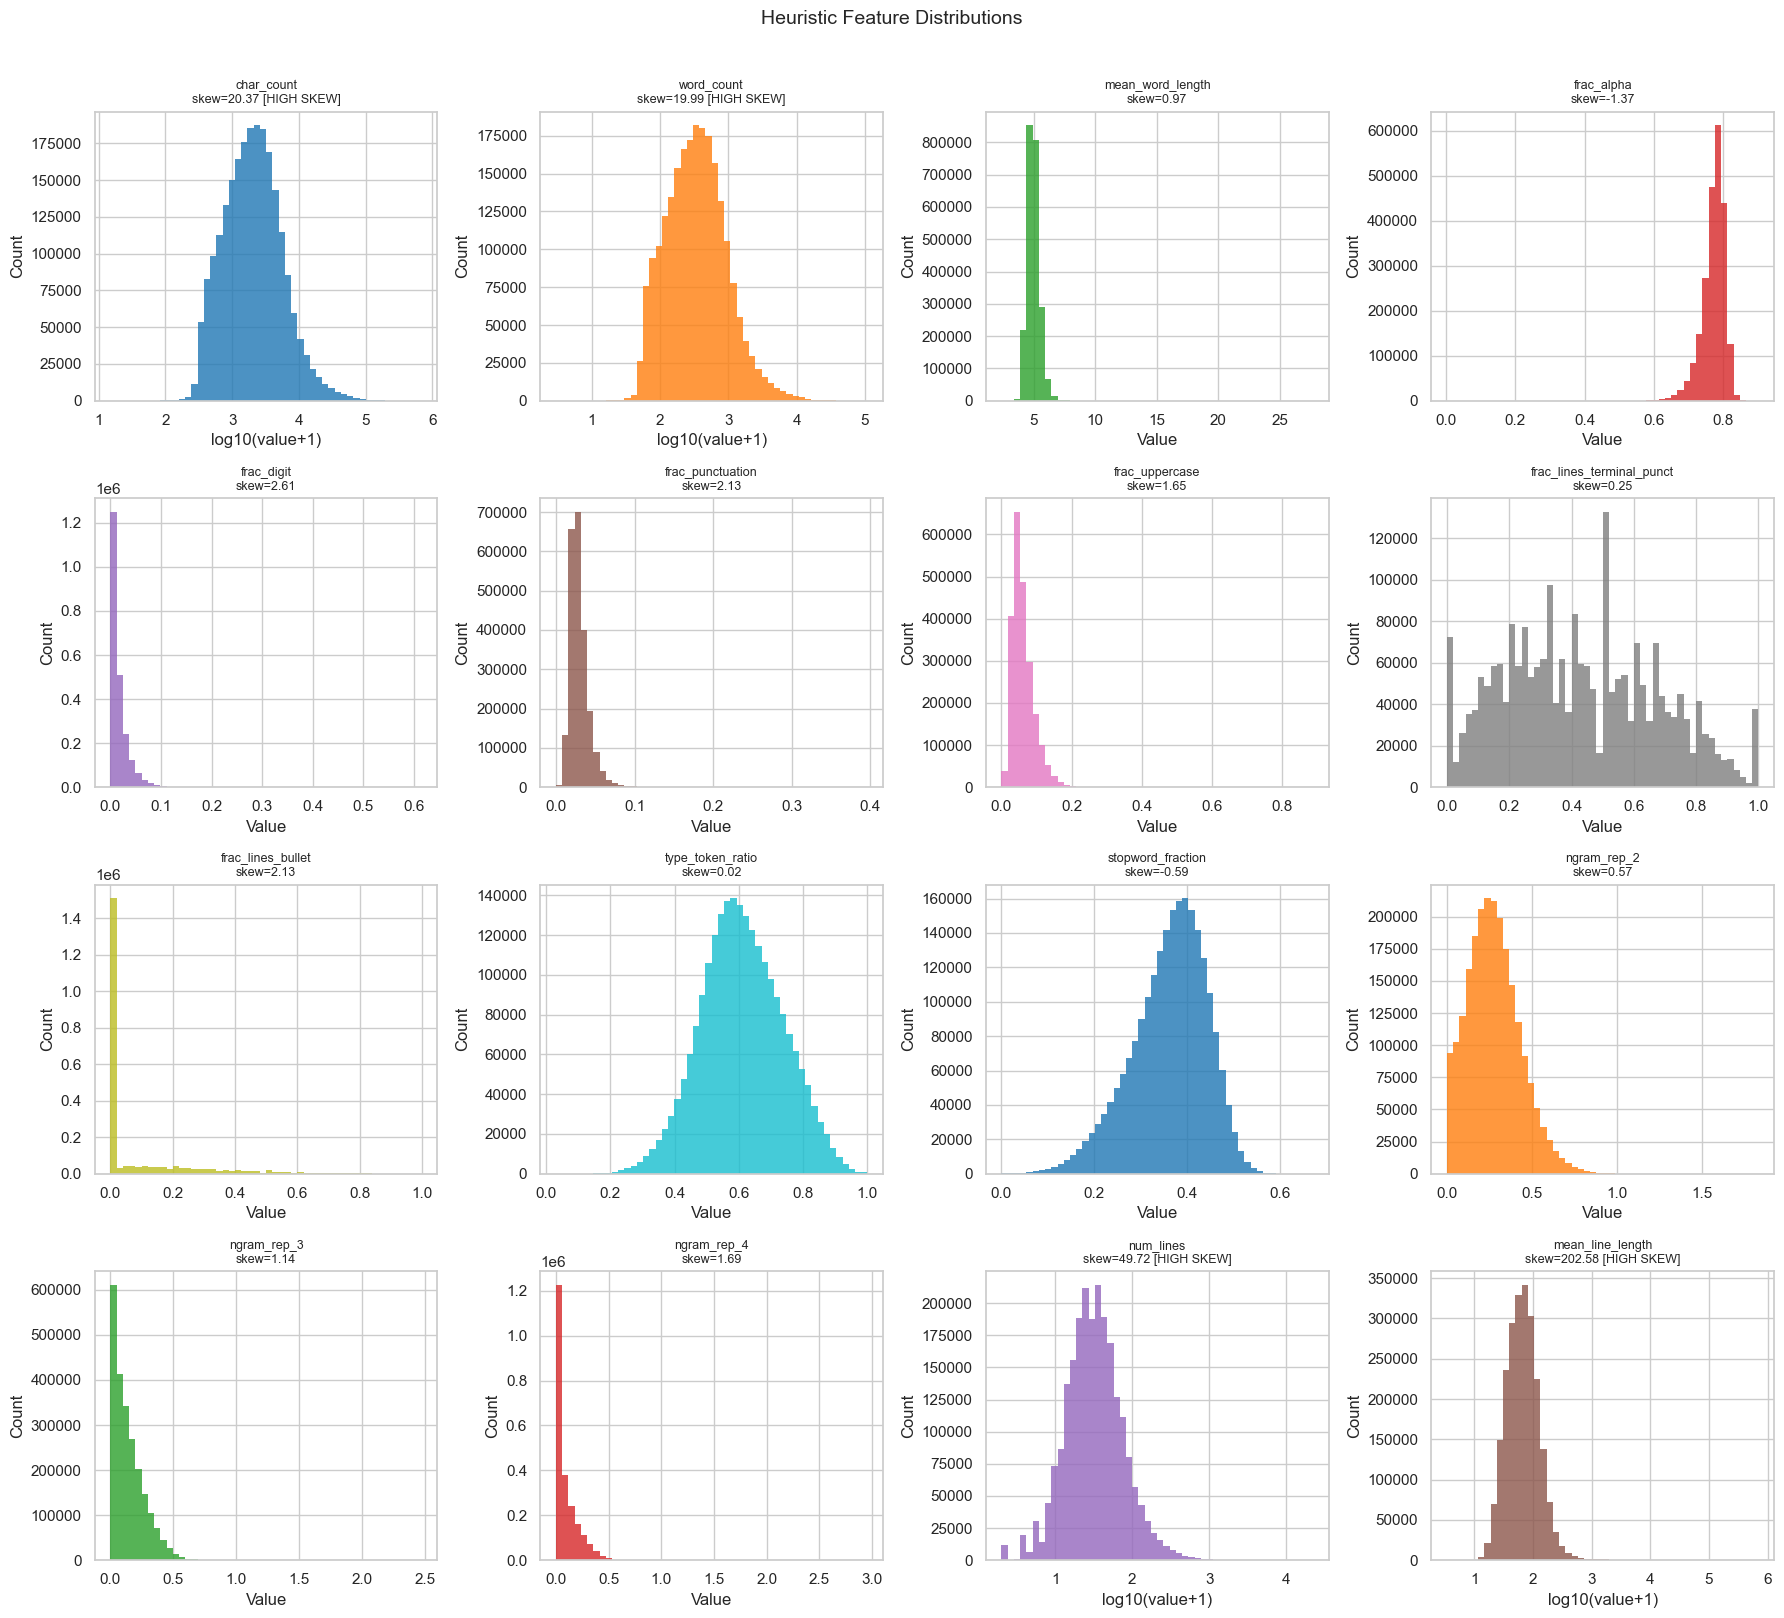

In [7]:
# --- Cell 7: Heuristic feature histograms (4x4 grid) ---

HEURISTIC_COLS = [
    'char_count', 'word_count', 'mean_word_length', 'frac_alpha',
    'frac_digit', 'frac_punctuation', 'frac_uppercase', 'frac_lines_terminal_punct',
    'frac_lines_bullet', 'type_token_ratio', 'stopword_fraction',
    'ngram_rep_2', 'ngram_rep_3', 'ngram_rep_4',
    'num_lines', 'mean_line_length'
]
# Keep only columns present in dataframe
HEURISTIC_COLS = [c for c in HEURISTIC_COLS if c in df.columns]
print(f'Plotting {len(HEURISTIC_COLS)} heuristic features')

# Flag near-zero variance or extreme skew
feat_stats = []
for col in HEURISTIC_COLS:
    s = df[col].dropna()
    from scipy.stats import skew
    sk = skew(s)
    feat_stats.append({'feature': col, 'std': s.std(), 'skewness': sk, 'n': len(s)})
feat_df = pd.DataFrame(feat_stats).set_index('feature')
low_var = feat_df[feat_df['std'] < 0.01]
high_skew = feat_df[feat_df['skewness'].abs() > 5]
if len(low_var):
    print(f'Near-zero variance features: {list(low_var.index)}')
if len(high_skew):
    print(f'Highly skewed features (|skew|>5): {list(high_skew.index)}')

n_cols_grid = 4
n_rows_grid = int(np.ceil(len(HEURISTIC_COLS) / n_cols_grid))
fig, axes = plt.subplots(n_rows_grid, n_cols_grid, figsize=(18, 4 * n_rows_grid))
axes = axes.flatten()

colors = plt.cm.tab10.colors
for i, col in enumerate(HEURISTIC_COLS):
    ax = axes[i]
    s = df[col].dropna()
    sk = feat_df.loc[col, 'skewness']
    # Use log scale for very skewed count features
    if col in ('char_count', 'word_count', 'num_lines', 'mean_line_length') and s.min() > 0:
        ax.hist(np.log10(s + 1), bins=50, color=colors[i % 10], edgecolor='none', alpha=0.8)
        ax.set_xlabel('log10(value+1)')
    else:
        ax.hist(s, bins=50, color=colors[i % 10], edgecolor='none', alpha=0.8)
        ax.set_xlabel('Value')
    flag = ' [HIGH SKEW]' if abs(sk) > 5 else ''
    ax.set_title(f'{col}\nskew={sk:.2f}{flag}', fontsize=9)
    ax.set_ylabel('Count')

for j in range(len(HEURISTIC_COLS), len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Heuristic Feature Distributions', fontsize=14, y=1.01)
savefig('01_heuristic_features.png')